### Instructions for API extraction  (SKIP)

To start using the notebook:
1. Install dependencies in your .venv:

```
pip install -r requirements.txt
```

2. Go onto https://developer.company-information.service.gov.uk/manage-applications/add, create a new application and create a new key to obtain the API key
3. Create a file named ```.env``` and add your Companies House API key as ```CH_API_KEY=your_actual_api_key_here```. The block below will automatically import your API key, keeping it out of the source control

In [1]:
# import os
# from dotenv import load_dotenv

In [2]:
# # Load your .env API key
# load_dotenv()

# CH_API_KEY = os.getenv("CH_API_KEY")

# if not CH_API_KEY:
#     raise ValueError("CH_API_KEY not found. Check your .env file.")

### Instructions for bulk download

Go onto https://download.companieshouse.gov.uk/en_output.html and download the zipped file for Companies Records.

In [3]:
import pandas as pd

In [4]:
CSV_PATH = "../data/raw/BasicCompanyDataAsOneFile-2026-06-01.csv"

In [5]:
# Count total rows
with open(CSV_PATH, "rb") as f:
    total_firms = sum(1 for _ in f) - 1  # subtract header row
print(f"Total companies in file: {total_firms:,}")

Total companies in file: 5,698,276


### EDA - Bulk Company Data

In [6]:
SAMPLE_N = 50_000
df = pd.read_csv(CSV_PATH, nrows=SAMPLE_N, low_memory=False)

date_cols = [
    "IncorporationDate", "DissolutionDate",
    "Accounts.NextDueDate", "Accounts.LastMadeUpDate",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

print(f"Shape: {df.shape}")

Shape: (50000, 55)


In [16]:
df.head()

,CompanyName,CompanyNumber,RegAddress.CareOf,RegAddress.POBox,RegAddress.AddressLine1,RegAddress.AddressLine2,RegAddress.PostTown,RegAddress.County,RegAddress.Country,RegAddress.PostCode,...,PreviousName_7.CONDATE,PreviousName_7.CompanyName,PreviousName_8.CONDATE,PreviousName_8.CompanyName,PreviousName_9.CONDATE,PreviousName_9.CompanyName,PreviousName_10.CONDATE,PreviousName_10.CompanyName,ConfStmtNextDueDate,ConfStmtLastMadeUpDate
0,! LTD,08209948,NaN,NaN,9 PRINCES SQUARE,NaN,HARROGATE,NaN,ENGLAND,HG1 1ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25/09/2026,11/09/2025
1,!ABRIDGE TAX LTD,16092999,NaN,NaN,82 GREAT NORTH ROAD,GREAT NORTH BUSINESS CENTRE,HATFIELD,NaN,UNITED KINGDOM,AL9 5BL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04/12/2026,20/11/2025
2,!BIG IMPACT GRAPHICS LIMITED,11743365,NaN,NaN,124 CITY ROAD,NaN,LONDON,NaN,NaN,EC1V 2NX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29/12/2026,15/12/2025
3,!FE NETWORK LIMITED,16873705,NaN,NaN,C/O AACSL ACCOUNTANT LIMITED,1ST FLOOR NORTH WESTGATE HOUSE,"HARLOW, ESSEX",NaN,UNITED KINGDOM,CM20 1YS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08/12/2026,NaN
4,!NFLECTION ADVISORY LIMITED,15073164,NaN,NaN,74 SANTERS LANE,NaN,POTTERS BAR,HERTFORDSHIRE,ENGLAND,EN6 2DA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28/08/2026,14/08/2025


In [8]:

df.dtypes

CompanyName                                      str
 CompanyNumber                                   str
RegAddress.CareOf                                str
RegAddress.POBox                                 str
RegAddress.AddressLine1                          str
 RegAddress.AddressLine2                         str
RegAddress.PostTown                              str
RegAddress.County                                str
RegAddress.Country                               str
RegAddress.PostCode                              str
CompanyCategory                                  str
CompanyStatus                                    str
CountryOfOrigin                                  str
DissolutionDate                        datetime64[s]
IncorporationDate                     datetime64[us]
Accounts.AccountRefDay                       float64
Accounts.AccountRefMonth                     float64
Accounts.NextDueDate                  datetime64[us]
Accounts.LastMadeUpDate               datetime

In [9]:
null_summary = df.isnull().sum().rename("null_count").to_frame()
null_summary["null_pct"] = (null_summary["null_count"] / len(df) * 100).round(1)
null_summary.sort_values("null_pct", ascending=False)

,null_count,null_pct
DissolutionDate,50000,100.0
PreviousName_9.CONDATE,49998,100.0
PreviousName_9.CompanyName,49998,100.0
PreviousName_7.CONDATE,49997,100.0
PreviousName_7.CompanyName,49997,100.0
PreviousName_8.CompanyName,49997,100.0
PreviousName_8.CONDATE,49997,100.0
PreviousName_10.CONDATE,49999,100.0
PreviousName_10.CompanyName,49999,100.0
PreviousName_6.CompanyName,49995,100.0


In [10]:
for col in ["CompanyCategory", "CompanyStatus", "CountryOfOrigin", "Accounts.AccountCategory"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- CompanyCategory ---
CompanyCategory
Private Limited Company                                                                      41321
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                         7423
Overseas Entity                                                                                285
Limited Liability Partnership                                                                  257
Limited Partnership                                                                            212
Community Interest Company                                                                     176
Charitable Incorporated Organisation                                                            88
Other company type                                                                              67
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)       61
Public Limited Company                                              

In [11]:
df.select_dtypes("number").describe()

,Accounts.AccountRefDay,Accounts.AccountRefMonth,Mortgages.NumMortCharges,Mortgages.NumMortOutstanding,Mortgages.NumMortPartSatisfied,Mortgages.NumMortSatisfied,LimitedPartnerships.NumGenPartners,LimitedPartnerships.NumLimPartners
count,49362.000000,49362.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.00000
mean,30.120903,6.457093,0.373500,0.213940,0.000340,0.15896,0.00440,0.01618
std,2.723617,3.599018,3.824815,1.190864,0.020491,3.52081,0.07029,0.61156
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
25%,30.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
50%,31.000000,6.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
75%,31.000000,10.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
max,31.000000,12.000000,718.000000,96.000000,2.000000,718.00000,3.00000,72.00000


In [12]:
df["SICCode.SicText_1"].value_counts().head(20)

SICCode.SicText_1
98000 - Residents property management                                        15113
68209 - Other letting and operating of own or leased real estate              4334
68100 - Buying and selling of own real estate                                 2799
68320 - Management of real estate on a fee or contract basis                  2094
99999 - Dormant Company                                                       1205
None Supplied                                                                 1153
82990 - Other business support service activities n.e.c.                      1086
70229 - Management consultancy activities other than financial management     1076
96090 - Other service activities n.e.c.                                        837
41100 - Development of building projects                                       804
62020 - Information technology consultancy activities                          753
74990 - Non-trading company                                          

<Axes: title={'center': 'Incorporations by Year'}, xlabel='IncorporationDate'>

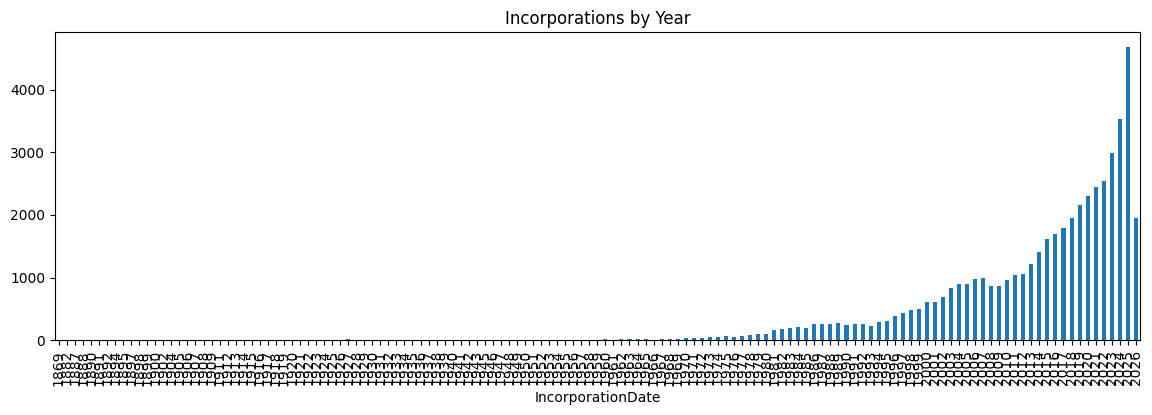

In [13]:
df["IncorporationDate"].dt.year.value_counts().sort_index().plot(
    kind="bar", figsize=(14, 4), title="Incorporations by Year"
)

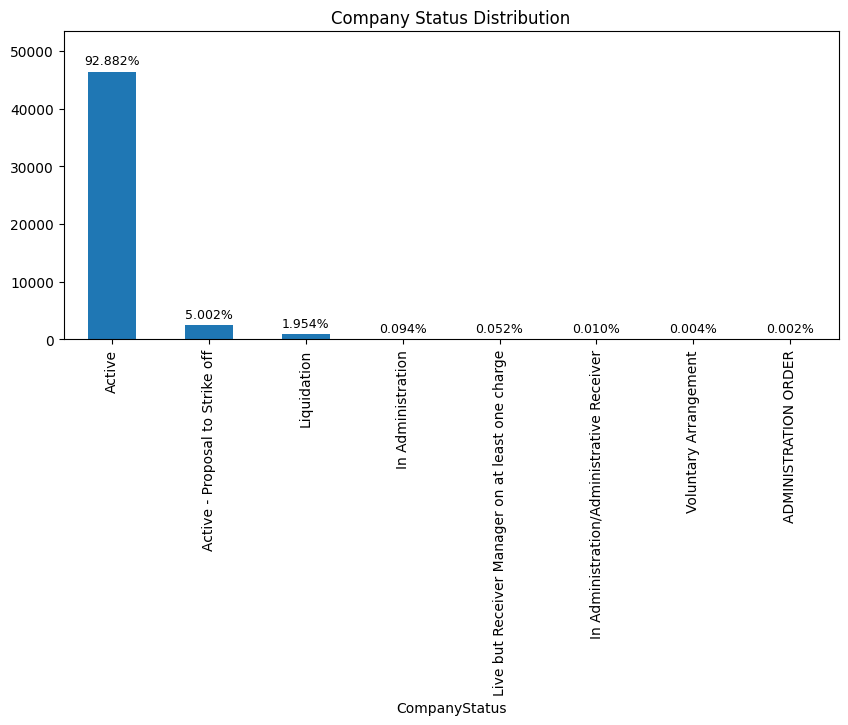

In [14]:
counts = df["CompanyStatus"].value_counts()
total = counts.sum()

ax = counts.plot(kind="bar", figsize=(10, 4), title="Company Status Distribution")

ax.bar_label(
    ax.containers[0],
    # labels=[f"{v:,}" for v in counts],          # absolute
    labels=[f"{v/total:.3%}" for v in counts],  # percentages
    padding=3, fontsize=9,
)
ax.margins(y=0.15)

### Full File Load & Segmentation (Turnover + Sectors)

#### 1. Tunrover: proxy via `Accounts.AccountCategory`
Read at https://www.gov.uk/government/publications/life-of-a-company-annual-requirements/life-of-a-company-part-1-accounts#medium-sized-company-accounts the categories of accounts.

In this dataset we have:

In [15]:
df['Accounts.AccountCategory'].value_counts()

Accounts.AccountCategory
MICRO ENTITY                   16957
DORMANT                        13136
TOTAL EXEMPTION FULL            8823
NO ACCOUNTS FILED               8678
UNAUDITED ABRIDGED               918
FULL                             398
SMALL                            296
AUDIT EXEMPTION SUBSIDIARY       285
TOTAL EXEMPTION SMALL            196
ACCOUNTS TYPE NOT AVAILABLE      189
GROUP                            102
MEDIUM                            18
AUDITED ABRIDGED                   3
FILING EXEMPTION SUBSIDIARY        1
Name: count, dtype: int64

According to the website these are (AFTER 6 April 2025):
- MICRO ENTITY: turnover < £1mln; balance sheet total < £500k; < 10 employees
- SMALL: turnover < £15mln; balance sheet total < £7.5mln; < 50 employees
- MEDIUM: turnover < £54mln; balance sheet total < £27mln; < 250 employees
- DORMANT: has had no ‘significant accounting transactions’ during the accounting period. A significant accounting transaction is one which the company should enter in its accounting records.
- FULL: The company has filed a full set of audited accounts. This is typically required for large companies that do not meet the criteria to be classified as micro, small, or medium-sized. Full accounts generally include a balance sheet, profit and loss account, notes, directors' report, and an auditors' report
- TOTAL EXEMPTION FULL: The company has taken advantage of the audit exemption available to small companies. This category allows a company to file unaudited accounts that contain a full balance sheet and a profit and loss account, provided it qualifies for audit exemption under the Companies Act 2006
- NO ACCOUNTS FILED: The company has an accounting category of 'NO ACCOUNTS FILED', which indicates that the company has not yet filed any accounts with Companies House. This status is often a prerequisite for filing certain types of accounts, such as dormant company accounts
- UNAUDITED ABRIDGED: The company has filed unaudited, abridged accounts. Abridged accounts contain a balance sheet and profit and loss account with fewer line items, offering less detail.
- AUDIT EXEMPTION SUBSIDIARY: The company is a subsidiary that has successfully claimed an exemption from the statutory audit requirement. This is available under Section 479A of the Companies Act 2006, typically when a parent company provides a guarantee for the subsidiary's liabilities and includes it in its own consolidated accounts.
- TOTAL EXEMPTION SMALL: This is an older account category. Historically, 'Total Exemption Small' was used for companies that would file a reduced set of accounts (often abbreviated) at Companies House, while 'Total Exemption Full' was for those filing a full balance sheet and profit and loss account.
- ACCOUNTS TYPE NOT AVAILABLE:	Placeholder for `blank`
- GROUP	The company is part of a group and files group accounts. A parent company with subsidiaries is generally required to prepare group accounts (consolidated accounts) unless an exemption, such as qualifying as a small group, applies.
- AUDITED ABRIDGED: The company has filed abridged accounts that have been audited. This is a less common combination, but it is possible when a small company produces abridged accounts but does not meet the conditions for an audit exemption.
- FILING EXEMPTION SUBSIDIARY:	The company is a subsidiary that has claimed an exemption from the requirement to file its own accounts. This is typically for a dormant subsidiary where the parent company has provided a guarantee and included it in its consolidated accounts, under Sections 394A or 448A of the Companies Act 2006.